Ejercicio 1.- Gestión de impresoras.
-------

Una gran empresa tiene sus oficinas centrales en un edificio de 20 plantas y en cada una de ellas tiene instaladas varias impresoras. El número total de impresoras es grande y cada día un equipo de mantenimiento pasa por todas ellas para decidir si se sustituye o no el cartucho de tóner. Los cartuchos pueden estar en tres estados: bueno, bajo o vacío. Cada día:
- El 8% de las impresoras con tóner en buen estado pasará a tenerlo bajo.

- El 40% de las impresoras que tenían el tóner bajo se quedarán sin tóner.

- Si mantenimiento encuentra una impresora con el cartucho de tóner vacío, lo sustituye por un cartucho nuevo. No se sustituyen cartuchos que no estén vacíos.

**a)** La empresa lleva ya algún tiempo gestionando sus impresoras de esta manera. ¿Qué porcentaje de las impresoras estarán funcionando (es decir, el cartucho de tóner **no estará vacío**, aunque puede estar bajo) habitualmente?


In [1]:
#Escribimos la matriz del sistema y encontramos sus autovalores
A=matrix(QQ,3,[[0.92,0,1],[0.08,0.6,0],[0,0.4,0]])##Importante aquí forzar a trabajar en QQ
show(A)
show(A.eigenvalues())

[23/25     0     1]
[ 2/25   3/5     0]
[    0   2/5     0]

[1, 0.07132037735886792?, 0.4486796226411321?]

In [2]:
def EsRegular(M):
    k=M.nrows()                    # Número de filas (que debe ser el mismo que el de columnas M.ncolumns())
    ceros=k^2-len(M.nonzero_positions())
    pasos=0
    while ceros>0 and 2^pasos<k^2: # Sale del bucle cuando 2^pasos>k^2 ó cuando ya no hay ceros
        pasos+=1
        M=M^2                      # Vamos a ir calculando con M, M^2, (M^2)^2=M^4, (M^4)^2=M^8, etc...
        ceros=k^2-len(M.nonzero_positions())
    return ceros==0    

In [3]:
EsRegular(A)

True

In [4]:
#Extraemos el autovector principal, que, como estamos ante una matriz de Markov, es el del autovalor 1.
AutP=(A-identity_matrix(3)).right_kernel().basis()[0]##Si no es en QQ, esta operación no encuentra la solución
AutP=AutP/sum(AutP)
show(AutP)

(25/32, 5/32, 1/16)

In [5]:
#Calculamos el porcentaje que suponen las impresoras en funcionamiento sobre el total.
#Para eso hay que tomar en consideración las dos primeras componentes del autovector.
porc=100*(AutP[0]+AutP[1])
print('El porcentaje de impresoras en funcionamiento será de un %s por ciento.' %porc.n(digits=4))#El digits=4 se ha puesto una vez visto el resultado

El porcentaje de impresoras en funcionamiento será de un 93.75 por ciento.


**b)** Se considera que ese porcentaje es un poco escaso, y convendr&iacute;a subirlo un 3% adicional. Para ello, se decide sustituir cada día por cartuchos nuevos un cierto porcentaje de  los cartuchos que estén bajos. Como no se sabe exactamente cuáles de esos cartuchos aguantarán un poco más, mantenimiento elige al azar los cartuchos bajos a sustituir (por tanto, el 40% de los sustituidos estarán entre los que se iban a quedar vacíos durante el día). ¿Qué proporción de cartuchos bajos hay que cambiar por cartuchos nuevos para lograr el objetivo marcado?

In [6]:
#Llamamos t a la proporción de cartuchos bajos que se sustituyen.
#Escribimos la nueva matriz del sistema y encontramos sus autovalores
var('t')
assume(t>0)
AA=matrix(3,[[92/100,t,1],[8/100,6/10*(1-t),0],[0,4/10*(1-t),0]])##Conviene escribir con notación racional
show(AA)
AAutP=(AA-identity_matrix(QQ,3)).right_kernel().basis()[0]
AAutP=AAutP/sum(AAutP)
show(AAutP)

[       23/25            t            1]
[        2/25 -3/5*t + 3/5            0]
[           0 -2/5*t + 2/5            0]

(-25/(4/(5*t/(t - 1) - 2) - 10/((t - 1)*(5*t/(t - 1) - 2)) - 25), -10/((t - 1)*(5*t/(t - 1) - 2)*(4/(5*t/(t - 1) - 2) - 10/((t - 1)*(5*t/(t - 1) - 2)) - 25)), 4/((5*t/(t - 1) - 2)*(4/(5*t/(t - 1) - 2) - 10/((t - 1)*(5*t/(t - 1) - 2)) - 25)))

In [7]:
#Averiguamos para qué t la proporción de impresoras en funcionamiento sube un 3%
Soluct=solve(100*(AAutP[0]+AAutP[1])==3+porc,t)[0]#El [0] por que solve devuelve la lista de soluciones (en este caso es única)
t0=Soluct.rhs()
print(t0)

256/841


In [8]:
#El porcentaje de cartuchos con el toner bajo que hay que sustituir es entonces
At0=AA.substitute(t=t0)
show(At0)
AAut0=(At0-identity_matrix(QQ,3)).right_kernel().basis()[0]
AAut0=AAut0/sum(AAut0)
show(AAut0)
porct0=100*(AAut0[0]+AAut0[1])
print('Con las nuevas medidas el porcentaje de cartuchos bajos que tendremos que sustituir será de %s por ciento,' %porct0.n(digits=4))
print('un %s por ciento más que con la política anterior.'%(porct0-porc))

[  23/25 256/841       1]
[   2/25 351/841       0]
[      0 234/841       0]

(245/288, 841/7200, 13/400)

Con las nuevas medidas el porcentaje de cartuchos bajos que tendremos que sustituir será de 96.75 por ciento,
un 3 por ciento más que con la política anterior.


Ejercicio 2.- Un modelo no lineal de depredador-presa.
-------

Supongamos que tenemos una población $X$ de un determinado depredador que se alimenta de una presa cuya población denotamos por $Y$. Se mide cada primavera el número de ejemplares. Si denotamos por $X_N$ el número de depredadores, y por $Y_N$ el de presas, en el año $N$ de observación, el modelo evoluciona según las relaciones
$$ X_{N+1}= a X_N+ bX_N Y_N \qquad \text{y} \qquad Y_{N+1}= c Y_N+ dX_N Y_N$$
para ciertos parámetros $a$, $b$, $c$ y $d$.

En ausencia de la presa $Y$, la población del depredador $X$ va decreciendo hasta su extinción, y así el  coeficiente $a$ en la ecuación será $<1$. Los encuentros entre una presa y un depredador (estimados por el producto $XY$) suponen un beneficio para la población de depredadores (coeficiente $b\ge0$). En cuanto a la población de presas, si no hubiera depredadores tendería a crecer (coeficiente $c\ge1$) mientras que los encuentros con un depredador resultan ser perjudiciales (coeficiente $d\le0$).

Para los datos iniciales $X_0=10, Y_0=42$ y los coeficientes $a=0.7$, $b=0.01$ ,$c=1.2$, $d=-0.02$, se pide:

**a)** Escribe el código que permita producir los valores de $X_N$ e $Y_N$ hasta un $N$ determinado. 

**b)** Dibuja en los mismos ejes y con colores distintos las gráficas $\{(N,X_N), \, N=0,\dots, 60\}, \ \{(N,Y_N), \, N=0,\dots, 60\}.$

**c)** Dibuja la gráfica $\{(X_N,Y_N), \, N=0,\dots, 60\}$.

_Sugerencia_: Haz los tres apartados simultáneamente.


**Atención:** este es un **modelo no lineal, por tanto no hay una formulación a partir de matrices.**

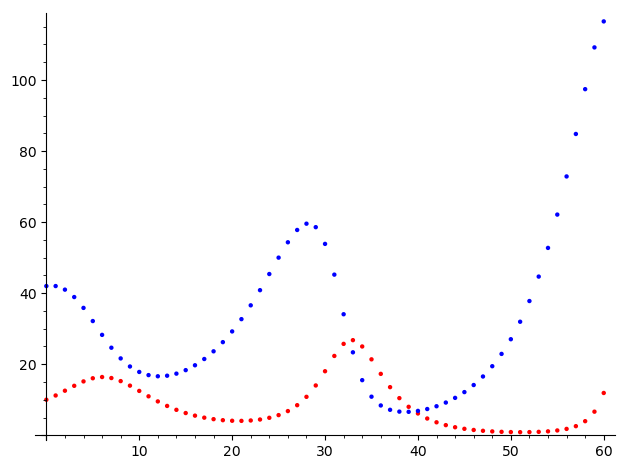

In [9]:
ListaX,ListaY,ListaXY=[],[],[]
X=10; Y=42
a=0.7;b=0.01;c=1.2;d=-0.02
for k in [0..60]:
    ListaXY.append((X,Y))
    ListaX.append((k,X))
    ListaY.append((k,Y))
    X,Y=(a*X+b*X*Y),(c*Y+d*X*Y)
points(ListaX,color='red')+points(ListaY)

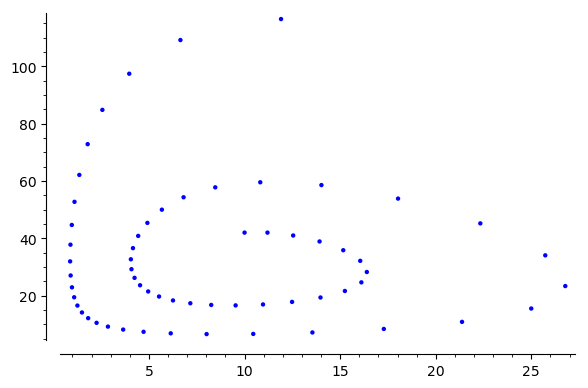

In [10]:
points(ListaXY)

Ejercicio 3.- Evolución de epidemias.
-------

Para tener una primera aproximación a la evolución de una epidemia, normalmente se usa un modelo **NO LINEAL** de propagación: el modelo **SIR.**

El modelo SIR toma su nombre de las iniciales de los tres tipos de población
que considera: **Susceptibles, Infectados y Recuperados**. El porcentaje de individuos de cada población en
función del tiempo  medido en semanas viene dado por:

$S_N$: Representa a los individuos Susceptibles, aquellos que pueden ser infectados.

$I_N$: Representa a la población portadora de la enfermedad y que por tanto, puede contagiarla.

$R_N$: es el porcentaje de individuos que ya han pasado la enfermedad y se han inmunizado (o han fallecido; en cualquier caso, ya no pueden volver a enfermar). 


 
Un individuo solo puede dejar de ser Susceptible si se Infecta,  y dejar de ser Infectado si pasa a la clase R. Es decir, el paso de una clase a otra es único. **Los porcentajes de infección $\beta$ y de recuperación $\gamma$ son los mismos para todos los individuos de una clase y se suponen positivos**.

**Término no lineal:** Buscamos un modelo **lo más sencillo posible**, en el que la población sana en el instante $N, \, S_N$ dependerá de una cierta función del estado anterior, $F(S_{N-1},I_{N-1})$. Por supuesto, si en un instante $N-1$ todo el mundo se ha contagiado y $S_{N-1}=0$, entonces debe ser $S_N=S_{N-1}$. Y si en un instante $ N-1$ ya no hay infectados, de modo que $I_{N-1}=0$, entonces también debe ser $S_N=S_{N-1}$ (porque no queda nadie que pueda contagiar la enfermedad). 

La función $F $ más simple que cumple estas dos condiciones es $F(S_{N-1},I_{N-1})=S_{N-1}-\beta S_{N-1}I_{N-1}$, donde el parámetro $\beta$ tiene que ver con la facilidad con la que se contagia la enfermedad.

Por tanto, en nuestro modelo consideraremos: 
$$S_N=S_{N-1} - \beta \, S_{N-1}I_{N-1}$$.
Por otro lado, cada semana hay un porcentaje $ \gamma \, I_{N-1} $ de individuos enfermos que pasan a la clase $R$, y un porcentaje $ \beta \, S_{N-1}I_{N-1}$ de nuevos infectados, de donde deducimos la ecuación para $I_N$,
$$
I_N=I_{N-1} +\beta\, S_{N-1}I_{N-1}-\gamma \, I_{N-1}
$$
y de forma similar podemos deducir la ecuación
$$
R_N=R_{N-1}+\gamma I_{N-1}
$$
para el porcentaje de individuos que no pueden volver a enfermar.

**a)** Partiendo de un dato inicial en el que el 99% de la población está sano,  hay un 1% de individuos enfermos, y nadie es inmune (es decir, $(S_0,I_0,R_0)=(0.99,0.01,0)$), tomando una probabilidad de contagio $\beta=0.7$, y una tasa de recuperación $\gamma=0.1$,  dibujar una gráfica de la evolución de las tres clases de población, cada una en un color distinto, a lo largo de un periodo de 40 semanas. 

**Atención:** este es un **modelo no lineal, por tanto no hay una formulación a partir de matrices.**

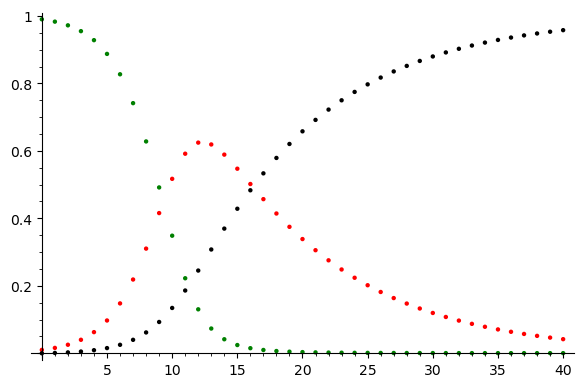

In [11]:
#a)
S,I,R=0.99,.01,0
Lista_S=[(0,S)]
Lista_I=[(0,I)]
Lista_R=[(0,R)]
gamma, beta=0.1,0.7
for k in [1..40]:
    S,I,R=S-beta*S*I,I+beta*S*I-gamma*I,R+gamma*I
    Lista_S.append((k,S))
    Lista_I.append((k,I))
    Lista_R.append((k,R))
    
dibujo=points(Lista_S,color='green')+points(Lista_I,color='red')+points(Lista_R,color='black')

dibujo

**b)** De la gráfica anterior se deduce que sin tomar medidas, en el pico más alto de la epidemia el porcentaje de enfermos es demasiado alto y durante varias semanas se colapsarían los servicios públicos. Por ello, antes de que se produzca un brote de la enfermedad, se realiza una campaña de vacunación que inmuniza a un porcentaje $P$ de la población sana, con lo que **los datos iniciales en el momento de aparecer la epidemia (cuando hay un 1% de infectados) cambian**. Representar  las gráficas de enfermos para distintos valores de inmunidad $P$ desde $0.05, 0.1, 0.15...$ hasta $0.45$, con una **gradación de colores del rojo cuando $P=0.05 $ al azul cuando $ P=0.55$**, para identificar gráficamente qué porcentaje $P$ es el que garantiza que en el pico máximo de la enfermedad, los individuos afectados estén por debajo del 20% del total. (Incluir en el dibujo una línea horizontal de color verde, que indique dónde está el 20%)

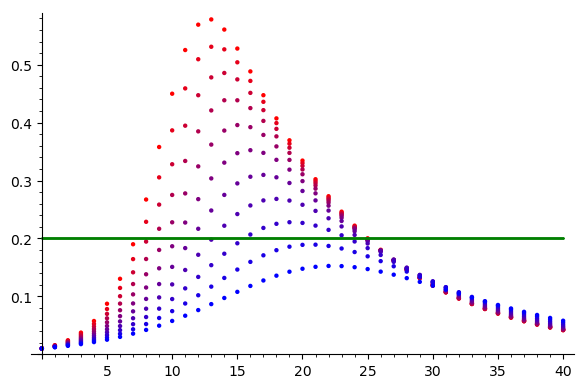

In [12]:
#b)
dibujob=Graphics()
for P in [0.05,0.1..0.55]:
    S,I,R=0.99-P,.01,P
    Lista_S=[(0,S)]
    Lista_I=[(0,I)]
    Lista_R=[(0,R)]
    gamma, beta=0.1,0.7
    for k in [1..40]:
        S,I,R=S-beta*S*I,I+beta*S*I-gamma*I,R+gamma*I
        Lista_I.append((k,I))
    dibujob+=points(Lista_I, color=(1-(P-0.05)/0.5,0,(P-0.05)/0.5))+plot(.2,x,0,40, color='green')
dibujob